**Name: Rudra P Patel**



**Roll No.: 25MCE023**


**Practical-3: Conventional Feed Forward Neural Network on MNIST. Write
code using PyTorch**

In [ ]:
# rnn model for mnist data ,
# and finding itteration loss and epoch loss

Mounted at /content/drive
Epoch [1/10] Loss: 0.3709, Train Acc: 0.8886, Val Acc: 0.9550
Epoch [2/10] Loss: 0.1476, Train Acc: 0.9557, Val Acc: 0.9690
Epoch [3/10] Loss: 0.1069, Train Acc: 0.9682, Val Acc: 0.9728
Epoch [4/10] Loss: 0.0871, Train Acc: 0.9725, Val Acc: 0.9768
Epoch [5/10] Loss: 0.0725, Train Acc: 0.9771, Val Acc: 0.9785
Epoch [6/10] Loss: 0.0631, Train Acc: 0.9795, Val Acc: 0.9810
Epoch [7/10] Loss: 0.0584, Train Acc: 0.9815, Val Acc: 0.9812
Epoch [8/10] Loss: 0.0522, Train Acc: 0.9833, Val Acc: 0.9830
Epoch [9/10] Loss: 0.0469, Train Acc: 0.9850, Val Acc: 0.9827
Epoch [10/10] Loss: 0.0425, Train Acc: 0.9864, Val Acc: 0.9838
Test Accuracy: 0.9795


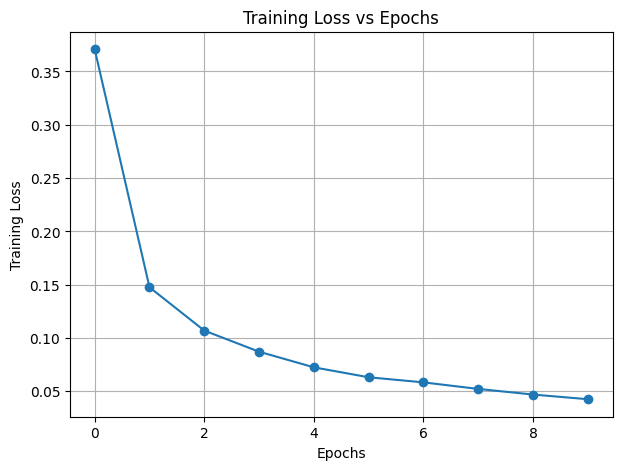

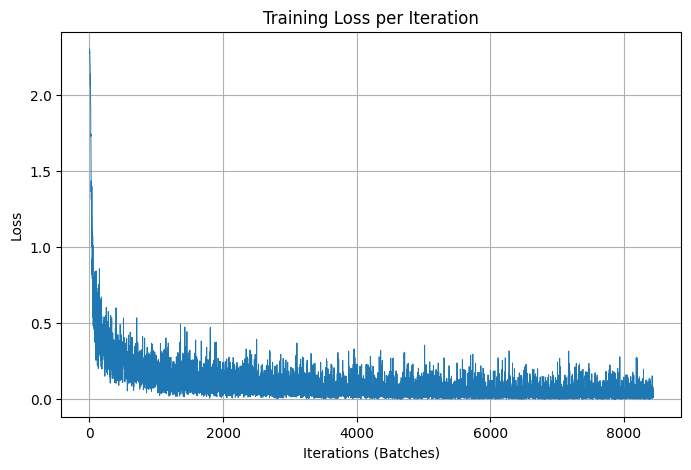

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# accessing csv from drive
from google.colab import drive
drive.mount('/content/drive')

file_path_test = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_test.csv'
file_path_train = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_train.csv'


train_df = pd.read_csv(file_path_train)
test_df = pd.read_csv(file_path_test)

# Normalizing pixel
X = train_df.iloc[:, 1:].values / 255.0
y = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

# train-validation spliting the train dataset into train and 1 for validate
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# creating the dataset class for using tensor in the inputs and outputs
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ann model class creation
# 28x28
# with first layer: 256 neuron
# second 128
# third 64
# fourth as 10
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.fc4(x)
        return x

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, epochs=10):
    epoch_losses = []
    iteration_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            # storeing iteration loss
            iteration_losses.append(loss.item())

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        train_acc = correct / len(train_loader.dataset)



        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return epoch_losses, iteration_losses

epoch_losses, iteration_losses = train_model(model, train_loader, val_loader, epochs=10)

# Test evaluation
model.eval()
test_correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")



# plot training loss
# for every epoch
plt.figure(figsize=(7,5))
plt.plot(epoch_losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()


# training loss for each iteration
plt.figure(figsize=(8,5))
plt.plot(iteration_losses, linewidth=0.7)
plt.xlabel("Iterations (Batches)")
plt.ylabel("Loss")
plt.title("Training Loss per Iteration")
plt.grid(True)
plt.show()


here with this code, we get to know that with every epoch the error is getting decrease, though in every iteration in an epoch the error is varing a lot but in each iteration it is varing

In [ ]:
# now lets try by using the differnt number of nurons in below

here in below adding a new layer of neurons in the front of 512 neorons and now comparing it with our previous and the currect one,

hoping that the accuracy should be a bit more due to addition of new layer leads to more learning

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch [1/10] Loss: 0.3530, Train Acc: 0.8908, Val Acc: 0.9570
Epoch [2/10] Loss: 0.1385, Train Acc: 0.9594, Val Acc: 0.9705
Epoch [3/10] Loss: 0.1014, Train Acc: 0.9699, Val Acc: 0.9718
Epoch [4/10] Loss: 0.0820, Train Acc: 0.9756, Val Acc: 0.9780
Epoch [5/10] Loss: 0.0696, Train Acc: 0.9795, Val Acc: 0.9758
Epoch [6/10] Loss: 0.0607, Train Acc: 0.9819, Val Acc: 0.9760
Epoch [7/10] Loss: 0.0557, Train Acc: 0.9833, Val Acc: 0.9782
Epoch [8/10] Loss: 0.0487, Train Acc: 0.9847, Val Acc: 0.9808
Epoch [9/10] Loss: 0.0449, Train Acc: 0.9865, Val Acc: 0.9813
Epoch [10/10] Loss: 0.0403, Train Acc: 0.9882, Val Acc: 0.9778
Test Accuracy: 0.9781


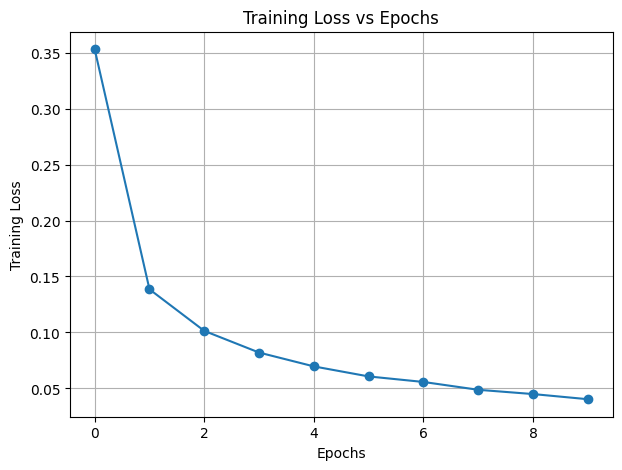

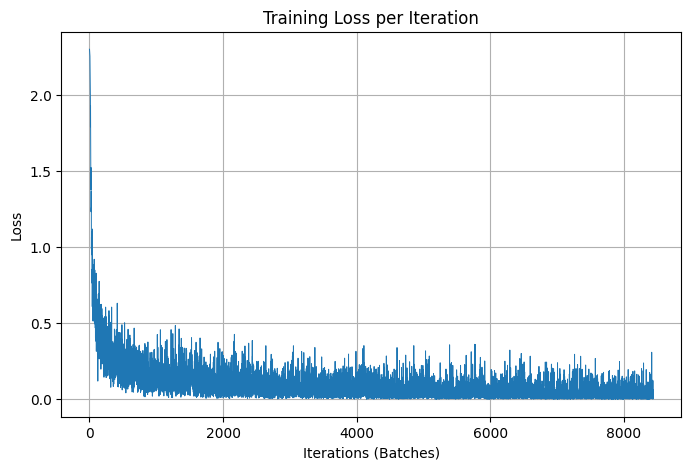

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# accessing csv from drive
from google.colab import drive
drive.mount('/content/drive')

file_path_test = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_test.csv'
file_path_train = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_train.csv'


train_df = pd.read_csv(file_path_train)
test_df = pd.read_csv(file_path_test)

# Normalizing pixel
X = train_df.iloc[:, 1:].values / 255.0
y = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

# train-validation spliting the train dataset into train and 1 for validate
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# creating the dataset class for using tensor in the inputs and outputs
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ann model class creation
# added layer: 512 neuron
# with first layer: 256 neuron
# second 128
# third 64
# fourth as 10
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, train_loader, val_loader, epochs=10):
    epoch_losses = []
    iteration_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            # storeing iteration loss
            iteration_losses.append(loss.item())

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        train_acc = correct / len(train_loader.dataset)



        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return epoch_losses, iteration_losses

epoch_losses, iteration_losses = train_model(model, train_loader, val_loader, epochs=10)

# Test evaluation
model.eval()
test_correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")



# plot training loss
# for every epoch
plt.figure(figsize=(7,5))
plt.plot(epoch_losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()


# training loss for each iteration
plt.figure(figsize=(8,5))
plt.plot(iteration_losses, linewidth=0.7)
plt.xlabel("Iterations (Batches)")
plt.ylabel("Loss")
plt.title("Training Loss per Iteration")
plt.grid(True)
plt.show()


there we can see that the accracy is low and also not only that but if we see the epoch error rate it initally was lesser than the first scenerio but later after 2-3 epoch it stoped decreasing rather it increase a bit and then again started decreasing in the later epoch

In [ ]:
# Now lets try another thing BELOW lets increase the number of epoch and lesser learning rate and check the change

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch [1/20] Loss: 0.4266, Train Acc: 0.8720, Val Acc: 0.9513
Epoch [2/20] Loss: 0.1498, Train Acc: 0.9551, Val Acc: 0.9695
Epoch [3/20] Loss: 0.1026, Train Acc: 0.9696, Val Acc: 0.9757
Epoch [4/20] Loss: 0.0801, Train Acc: 0.9765, Val Acc: 0.9755
Epoch [5/20] Loss: 0.0679, Train Acc: 0.9796, Val Acc: 0.9830
Epoch [6/20] Loss: 0.0546, Train Acc: 0.9838, Val Acc: 0.9803
Epoch [7/20] Loss: 0.0488, Train Acc: 0.9850, Val Acc: 0.9792
Epoch [8/20] Loss: 0.0424, Train Acc: 0.9873, Val Acc: 0.9832
Epoch [9/20] Loss: 0.0378, Train Acc: 0.9884, Val Acc: 0.9780
Epoch [10/20] Loss: 0.0349, Train Acc: 0.9890, Val Acc: 0.9813
Epoch [11/20] Loss: 0.0294, Train Acc: 0.9909, Val Acc: 0.9825
Epoch [12/20] Loss: 0.0277, Train Acc: 0.9915, Val Acc: 0.9815
Epoch [13/20] Loss: 0.0277, Train Acc: 0.9911, Val Acc: 0.9820
Epoch [14/20] Loss: 0.0220, Train Acc: 0.9930, Val Acc: 0.984

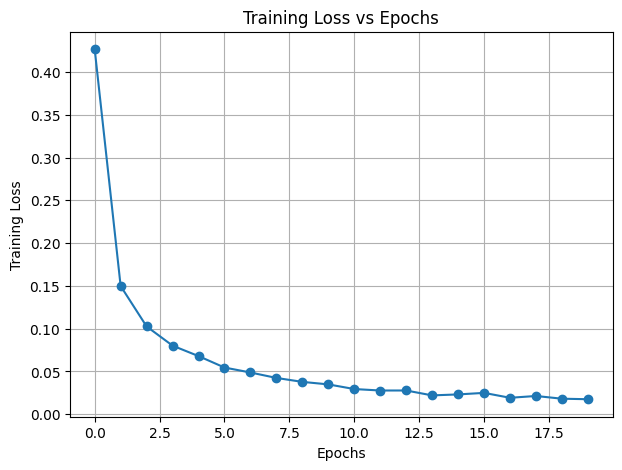

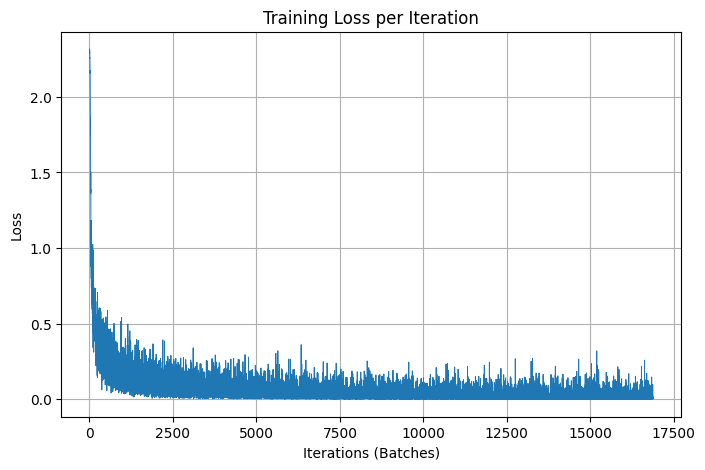

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# accessing csv from drive
from google.colab import drive
drive.mount('/content/drive')

file_path_test = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_test.csv'
file_path_train = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_train.csv'


train_df = pd.read_csv(file_path_train)
test_df = pd.read_csv(file_path_test)

# Normalizing pixel
X = train_df.iloc[:, 1:].values / 255.0
y = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

# train-validation spliting the train dataset into train and 1 for validate
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# creating the dataset class for using tensor in the inputs and outputs
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# ann model class creation
# with first layer: 256 neuron
# second 128
# third 64
# fourth as 10
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.relu(self.fc4(x))
        x = self.fc5(x)
        return x

# training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

def train_model(model, train_loader, val_loader, epochs=20):
    epoch_losses = []
    iteration_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            # storeing iteration loss
            iteration_losses.append(loss.item())

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        train_acc = correct / len(train_loader.dataset)



        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return epoch_losses, iteration_losses

epoch_losses, iteration_losses = train_model(model, train_loader, val_loader, epochs=20)

# Test evaluation
model.eval()
test_correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")



# plot training loss
# for every epoch
plt.figure(figsize=(7,5))
plt.plot(epoch_losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()


# training loss for each iteration
plt.figure(figsize=(8,5))
plt.plot(iteration_losses, linewidth=0.7)
plt.xlabel("Iterations (Batches)")
plt.ylabel("Loss")
plt.title("Training Loss per Iteration")
plt.grid(True)
plt.show()


yeh as we can see here we got 0.9832 accurcy which is best then all

now below lets use leakyRELU and lets see wht is the accuary for that

Mounted at /content/drive
Epoch [1/20] Loss: 0.4250, Train Acc: 0.8667, Val Acc: 0.9548
Epoch [2/20] Loss: 0.1527, Train Acc: 0.9551, Val Acc: 0.9698
Epoch [3/20] Loss: 0.1072, Train Acc: 0.9679, Val Acc: 0.9753
Epoch [4/20] Loss: 0.0843, Train Acc: 0.9747, Val Acc: 0.9752
Epoch [5/20] Loss: 0.0685, Train Acc: 0.9794, Val Acc: 0.9778
Epoch [6/20] Loss: 0.0543, Train Acc: 0.9833, Val Acc: 0.9792
Epoch [7/20] Loss: 0.0481, Train Acc: 0.9849, Val Acc: 0.9782
Epoch [8/20] Loss: 0.0429, Train Acc: 0.9866, Val Acc: 0.9828
Epoch [9/20] Loss: 0.0381, Train Acc: 0.9883, Val Acc: 0.9823
Epoch [10/20] Loss: 0.0359, Train Acc: 0.9888, Val Acc: 0.9857
Epoch [11/20] Loss: 0.0300, Train Acc: 0.9901, Val Acc: 0.9843
Epoch [12/20] Loss: 0.0294, Train Acc: 0.9908, Val Acc: 0.9837
Epoch [13/20] Loss: 0.0262, Train Acc: 0.9921, Val Acc: 0.9840
Epoch [14/20] Loss: 0.0251, Train Acc: 0.9921, Val Acc: 0.9855
Epoch [15/20] Loss: 0.0227, Train Acc: 0.9932, Val Acc: 0.9843
Epoch [16/20] Loss: 0.0225, Train Acc:

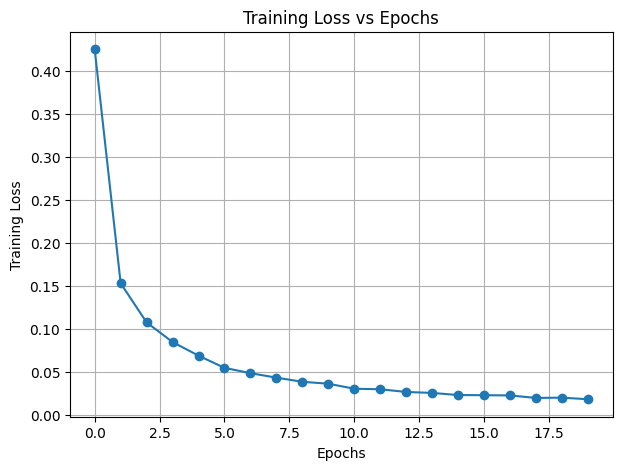

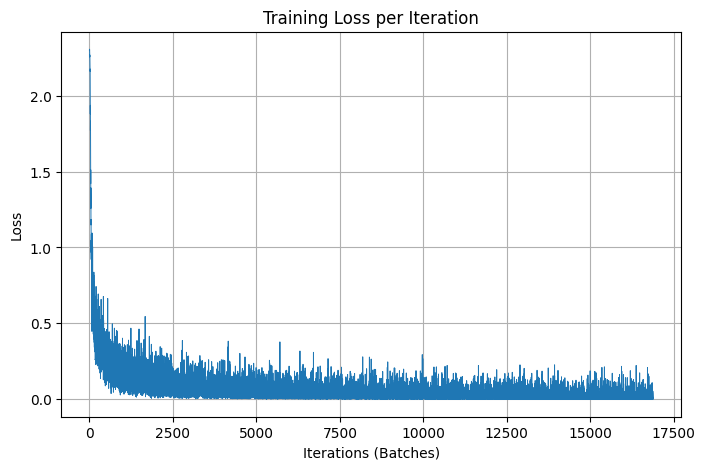

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

file_path_test = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_test.csv'
file_path_train = '/content/drive/MyDrive/Colab Notebooks/Files/mnist_train.csv'

train_df = pd.read_csv(file_path_train)
test_df = pd.read_csv(file_path_test)

X = train_df.iloc[:, 1:].values / 255.0
y = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

# train-validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

# Dataset class
class MNISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MNISTDataset(X_train, y_train)
val_dataset = MNISTDataset(X_val, y_val)
test_dataset = MNISTDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# LeakyReLU
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, 10)

        self.act = nn.LeakyReLU(negative_slope=0.01)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.dropout(x)
        x = self.act(self.fc2(x))
        x = self.dropout(x)
        x = self.act(self.fc3(x))
        x = self.dropout(x)
        x = self.act(self.fc4(x))
        x = self.fc5(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ANN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

def train_model(model, train_loader, val_loader, epochs=20):
    epoch_losses = []
    iteration_losses = []

    for epoch in range(epochs):
        model.train()
        total_loss, correct = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            iteration_losses.append(loss.item())

            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct += (preds == y_batch).sum().item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

        train_acc = correct / len(train_loader.dataset)

        # validation
        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                preds = outputs.argmax(1)
                val_correct += (preds == y_batch).sum().item()

        val_acc = val_correct / len(val_loader.dataset)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Loss: {avg_loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    return epoch_losses, iteration_losses

epoch_losses, iteration_losses = train_model(model, train_loader, val_loader, epochs=20)

# test
model.eval()
test_correct = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(1)
        test_correct += (preds == y_batch).sum().item()

print(f"Test Accuracy: {test_correct / len(test_loader.dataset):.4f}")

# plot epoch loss
plt.figure(figsize=(7,5))
plt.plot(epoch_losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()

# plot iteration loss
plt.figure(figsize=(8,5))
plt.plot(iteration_losses, linewidth=0.7)
plt.xlabel("Iterations (Batches)")
plt.ylabel("Loss")
plt.title("Training Loss per Iteration")
plt.grid(True)
plt.show()

ohhhhhhh still not better, though initially we saw that it was just going to cross the margin but unfortuanly we are unable to

here we can see with use of leaky relu too the acuarrcy is not that improved,

but here we can see that the vali accuracy was much higher in early stages, compare to the runtime of the previous algo